# 02 — Clustering Comparison

**Goal:** Compare 3 clustering methods, select the best one for hotspot detection.

| Method | Type | How it finds clusters |
|--------|------|----------------------|
| KMeans | Centroid-based | Minimizes distance to K centers |
| Agglomerative | Hierarchical | Merges closest points bottom-up |
| DBSCAN | Density-based | Groups dense regions, marks sparse as noise |

**Evaluation:** Silhouette Score (higher = better separated clusters)

#  Imports and project root

In [ ]:
import sys
import os


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

%matplotlib inline

# Load and filter data


In [4]:
crashes_df = pd.read_csv('/Users/omerpoyraz/Desktop/AI Eng/MLOps/insurance_mlops/data/processed/crashes_cleaned.csv')

# Filter injury/fatal crashes
killed = crashes_df[crashes_df['injuries_fatal'] > 0]
injured = crashes_df[
    (crashes_df['injuries_total'] > 0) &
    (crashes_df['injuries_fatal'] == 0)
]
injury_df = pd.concat([killed, injured], ignore_index=True)

coords = injury_df[['longitude', 'latitude']].values
print(f"Clustering on {len(coords):,} injury/fatal crashes")

Clustering on 8,461 injury/fatal crashes




---
## 1. Find Optimal K
Run KMeans for K=2 to 10. Evaluate with both inertia (elbow) and silhouette score.

# Elbow + Silhouette analysis


In [5]:
k_range = range(2, 20)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(coords, labels))
    print(f"K={k}: Inertia={km.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

K=2: Inertia=39.39, Silhouette=0.4828
K=3: Inertia=28.36, Silhouette=0.3751
K=4: Inertia=21.25, Silhouette=0.3961
K=5: Inertia=16.46, Silhouette=0.4095
K=6: Inertia=13.47, Silhouette=0.4187
K=7: Inertia=11.35, Silhouette=0.4067
K=8: Inertia=9.87, Silhouette=0.4048
K=9: Inertia=8.86, Silhouette=0.3866
K=10: Inertia=8.10, Silhouette=0.3751
K=11: Inertia=7.41, Silhouette=0.3753
K=12: Inertia=6.75, Silhouette=0.3766
K=13: Inertia=6.22, Silhouette=0.3760
K=14: Inertia=5.77, Silhouette=0.3739
K=15: Inertia=5.39, Silhouette=0.3744
K=16: Inertia=5.02, Silhouette=0.3766
K=17: Inertia=4.70, Silhouette=0.3753
K=18: Inertia=4.45, Silhouette=0.3752
K=19: Inertia=4.18, Silhouette=0.3739


#  Plot elbow and silhouette


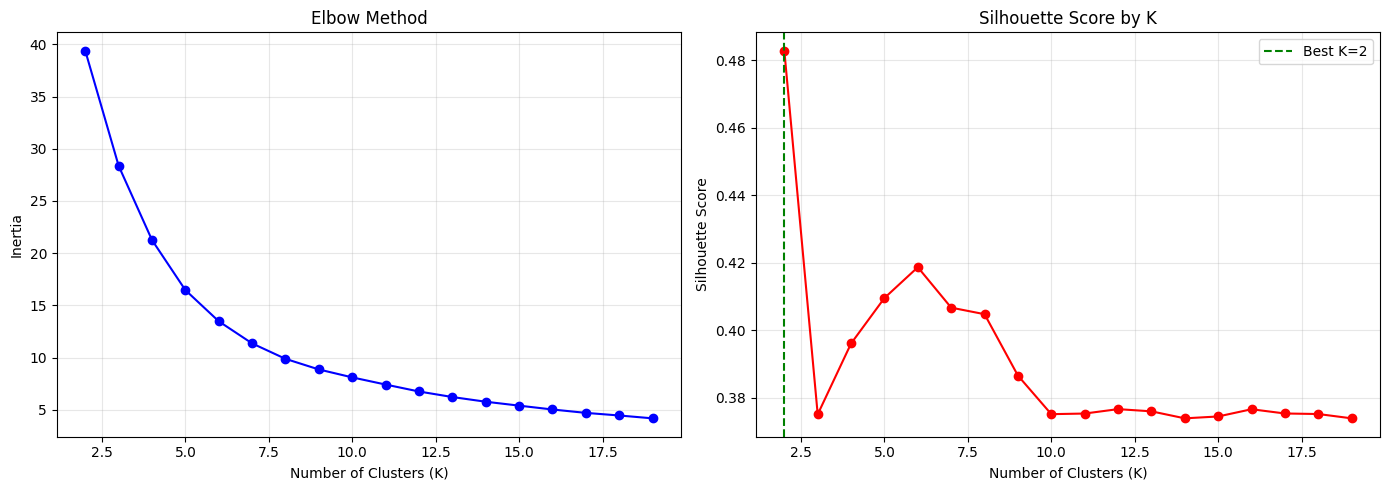


Best K by silhouette score: 2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

# Mark the best K
best_k = list(k_range)[np.argmax(silhouette_scores)]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nBest K by silhouette score: {best_k}")

## 2. Run All Three Methods
Using the best K from silhouette analysis.

In [7]:
K = 6
print(f"Using K={K} for comparison\n")

results = {}

# --- KMeans ---
km = KMeans(n_clusters=K, random_state=42, n_init=10)
km_labels = km.fit_predict(coords)
km_sil = silhouette_score(coords, km_labels)
results['KMeans'] = {
    'labels': km_labels,
    'score': km_sil,
    'centers': km.cluster_centers_,
}
print(f"KMeans:         Silhouette = {km_sil:.4f}")

# --- Agglomerative ---
ac = AgglomerativeClustering(n_clusters=K)
ac_labels = ac.fit_predict(coords)
ac_sil = silhouette_score(coords, ac_labels)

# Compute centers manually (agglomerative doesn't store them)
ac_centers = np.array([
    coords[ac_labels == i].mean(axis=0) for i in range(K)
])
results['Agglomerative'] = {
    'labels': ac_labels,
    'score': ac_sil,
    'centers': ac_centers,
}
print(f"Agglomerative:  Silhouette = {ac_sil:.4f}")

# --- DBSCAN ---
db = DBSCAN(eps=0.001, min_samples=50)
db_labels = db.fit_predict(coords)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

if n_clusters_db >= 2:
    mask = db_labels != -1
    db_sil = silhouette_score(coords[mask], db_labels[mask])
else:
    db_sil = -1

db_centers = np.array([
    coords[db_labels == i].mean(axis=0) for i in range(n_clusters_db)
])
results['DBSCAN'] = {
    'labels': db_labels,
    'score': db_sil,
    'centers': db_centers,
    'n_clusters': n_clusters_db,
    'noise_points': n_noise,
}
print(f"DBSCAN:         Silhouette = {db_sil:.4f} (K={n_clusters_db}, noise={n_noise:,})")

Using K=6 for comparison

KMeans:         Silhouette = 0.4187
Agglomerative:  Silhouette = 0.3319
DBSCAN:         Silhouette = -1.0000 (K=0, noise=8,461)


# Dendrogram

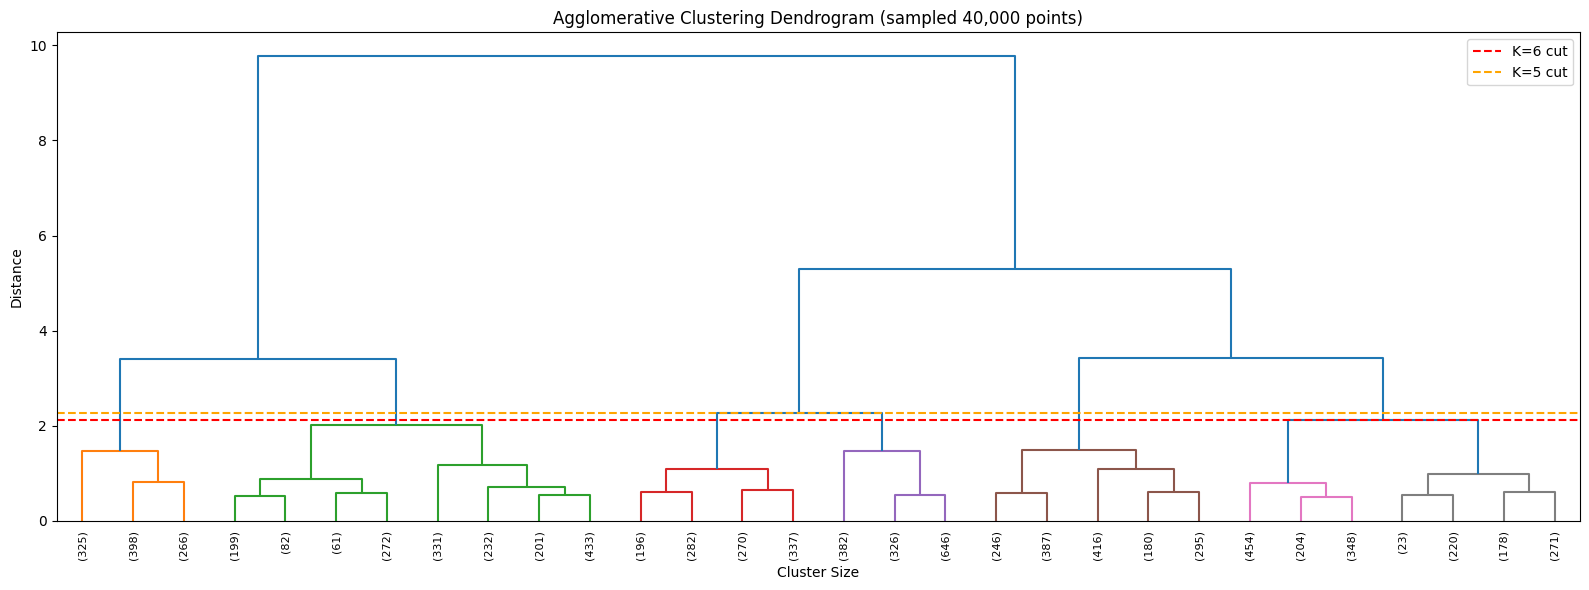

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample_size = 40000
if len(coords) > sample_size:
    np.random.seed(42)
    sample_idx = np.random.choice(len(coords), sample_size, replace=False)
    sample_coords = coords[sample_idx]
else:
    sample_coords = coords

Z = linkage(sample_coords, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
    color_threshold=Z[-6, 2],
)
ax.set_title('Agglomerative Clustering Dendrogram (sampled 40,000 points)')
ax.set_xlabel('Cluster Size')
ax.set_ylabel('Distance')
ax.axhline(y=Z[-6, 2], color='red', linestyle='--', label='K=6 cut')
ax.axhline(y=Z[-5, 2], color='orange', linestyle='--', label='K=5 cut')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Visual Comparison — Scatter Plots


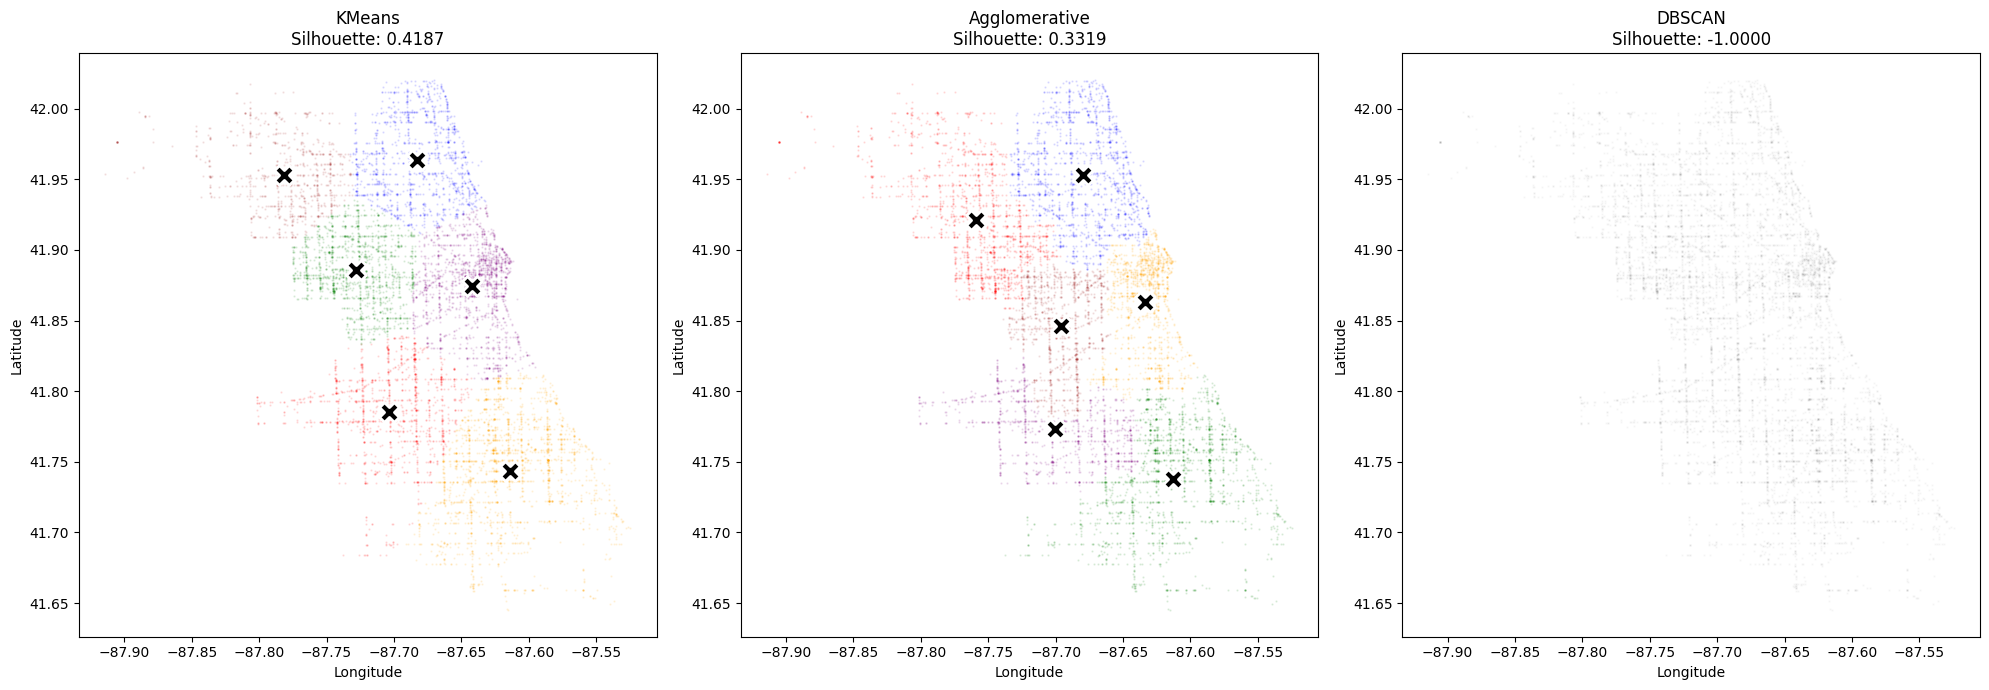

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']

for idx, (name, data) in enumerate(results.items()):
    ax = axes[idx]
    labels = data['labels']

    if name == 'DBSCAN':
        noise_mask = labels == -1
        ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
                   s=0.5, alpha=0.05, color='gray', label='Noise')
        for i in range(data['n_clusters']):
            mask = labels == i
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       s=0.5, alpha=0.1, color=colors[i % len(colors)])
    else:
        for i in range(K):
            mask = labels == i
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       s=0.5, alpha=0.1, color=colors[i % len(colors)])

    centers = data['centers']
    if len(centers) > 0:
        ax.scatter(centers[:, 0], centers[:, 1],
                   s=200, c='black', marker='X', edgecolors='white', linewidth=2, zorder=5)
    
    ax.set_title(f"{name}\nSilhouette: {data['score']:.4f}")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## 4. Interactive Maps — Folium


In [12]:
ranked = sorted(results.items(), key=lambda x: x[1]['score'], reverse=True)

map_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink']

for name, data in ranked[:2]:
    print(f"\n--- {name} (Silhouette: {data['score']:.4f}) ---")

    m = folium.Map(location=[41.8781, -87.6298], zoom_start=10)

    centers = data['centers']
    labels = data['labels']

    for i, center in enumerate(centers):
        count = (labels == i).sum()

        folium.CircleMarker(
            location=[center[1], center[0]],
            radius=count / 200,
            color=map_colors[i % len(map_colors)],
            fill=True,
            fill_opacity=0.7,
            popup=f"Cluster {i}: {count:,} crashes",
        ).add_to(m)

    # Save to HTML and open in browser
    filename = f"data/processed/map_{name.lower()}.html"
    m.save(filename)
    print(f"Saved map to {filename} — open in browser to view")


--- KMeans (Silhouette: 0.4175) ---
Saved map to data/processed/map_kmeans.html — open in browser to view

--- Agglomerative (Silhouette: 0.3474) ---
Saved map to data/processed/map_agglomerative.html — open in browser to view


## 5. Final Comparison


In [10]:
comparison = []
for name, data in results.items():
    row = {
        'Method': name,
        'Silhouette Score': round(data['score'], 4),
        'N Clusters': data.get('n_clusters', K),
    }
    if name == 'DBSCAN':
        row['Noise Points'] = data['noise_points']
    else:
        row['Noise Points'] = 0
    comparison.append(row)

comp_df = pd.DataFrame(comparison).sort_values('Silhouette Score', ascending=False)
print("=== Clustering Method Comparison ===\n")
print(comp_df.to_string(index=False))

winner = comp_df.iloc[0]['Method']
print(f"\n✅ Winner: {winner}")

=== Clustering Method Comparison ===

       Method  Silhouette Score  N Clusters  Noise Points
       KMeans            0.4187           6             0
Agglomerative            0.3319           6             0
       DBSCAN           -1.0000           0          8461

✅ Winner: KMeans


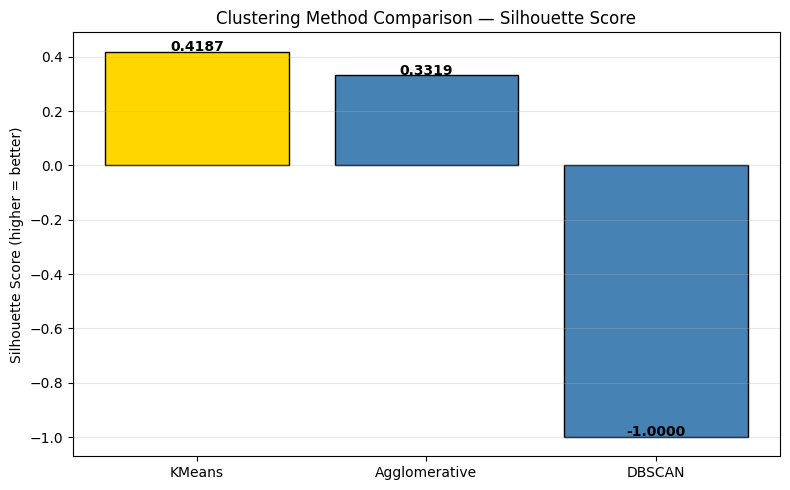

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['gold' if m == winner else 'steelblue' for m in comp_df['Method']]
ax.bar(comp_df['Method'], comp_df['Silhouette Score'], color=colors_bar, edgecolor='black')
ax.set_title('Clustering Method Comparison — Silhouette Score')
ax.set_ylabel('Silhouette Score (higher = better)')
ax.grid(axis='y', alpha=0.3)

for i, (method, score) in enumerate(zip(comp_df['Method'], comp_df['Silhouette Score'])):
    ax.text(i, score + 0.002, f"{score:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Save Winner's Cluster Summary


In [12]:
winner_data = results[winner]
centers = winner_data['centers']
labels = winner_data['labels']

cluster_summary = pd.DataFrame({
    'cluster': range(len(centers)),
    'longitude': centers[:, 0],
    'latitude': centers[:, 1],
    'cnt': [(labels == i).sum() for i in range(len(centers))],
})

cluster_summary = cluster_summary.sort_values('cnt', ascending=False, ignore_index=True)
cluster_summary['cluster'] = cluster_summary.index

print(f"Cluster summary ({winner}):\n")
print(cluster_summary.to_string(index=False))

cluster_summary.to_csv('/Users/omerpoyraz/Desktop/AI Eng/MLOps/insurance_mlops/data/processed/cluster_summary.csv', index=False)
print(f"\nSaved to data/processed/cluster_summary.csv")

Cluster summary (KMeans):

 cluster  longitude  latitude  cnt
       0 -87.614076 41.743205 2026
       1 -87.642023 41.874497 1664
       2 -87.728016 41.885659 1490
       3 -87.703853 41.785227 1290
       4 -87.682556 41.963904 1211
       5 -87.781432 41.953177  780

Saved to data/processed/cluster_summary.csv


---
### Conclusion

| Decision | Choice | Justification |
|----------|--------|---------------|
| **Method** | [fill after running] | Highest silhouette score |
| **K** | [fill after running] | Peak of silhouette curve |

**Next:** Notebook 03 — Model Comparison & Training